# Final Project Results

## GCN Baseline

In [9]:
import sys
from pathlib import Path

# Allows importing from the project root
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(project_root))


Imports

In [10]:
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

from src.gcn_baseline import run_experiment


Pick dataset

In [11]:
dataset_name = "CiteSeer"  # "CiteSeer" or "Cora"

if dataset_name.lower() == "citeseer":
    dataset_name = "CiteSeer"

dataset_name


'CiteSeer'

Run the GCN experiment

In [12]:
model, dataset, data, results = run_experiment(dataset_name, epochs=200)

run_path = Path(results["run_dir"])
plot_path = Path(results["plot_dir"])
losses = results["losses"]
val_accuracies = results["val_accuracies"]

model


Dataset: CiteSeer
Nodes: 3327
Edges: 9104
Features per node: 3703
Classes: 6
Train nodes: 120
Validation nodes: 500
Test nodes: 1000
Epoch: 1 Loss: 1.7917 Val acc: 0.168
Epoch: 20 Loss: 1.6376 Val acc: 0.636
Epoch: 40 Loss: 1.3733 Val acc: 0.672
Epoch: 60 Loss: 1.0847 Val acc: 0.69
Epoch: 80 Loss: 0.8378 Val acc: 0.696
Epoch: 100 Loss: 0.7567 Val acc: 0.708
Epoch: 120 Loss: 0.6399 Val acc: 0.712
Epoch: 140 Loss: 0.5525 Val acc: 0.712
Epoch: 160 Loss: 0.4713 Val acc: 0.714
Epoch: 180 Loss: 0.4558 Val acc: 0.71
Epoch: 200 Loss: 0.4351 Val acc: 0.706

Final results:
Train accuracy: 0.9917
Validation accuracy: 0.706
Test accuracy: 0.726
Macro F1: 0.6974
Weighted F1: 0.7304
Saved run to: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\runs\gcn\20260502_153414_CiteSeer_GCN
Plots go to: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_153414_CiteSeer_GCN


GCN(
  (conv1): GCNConv(3703, 16)
  (conv2): GCNConv(16, 6)
)

Tables

In [13]:
dataset_table = pd.DataFrame([
    {
        "Dataset": dataset.name,
        "Nodes": data.num_nodes,
        "Edges": data.num_edges,
        "Avg Degree": data.num_edges / data.num_nodes,
        "Density": data.num_edges / (data.num_nodes * (data.num_nodes - 1)),
        "Features": dataset.num_node_features,
        "Classes": dataset.num_classes,
        "Train": int(data.train_mask.sum()),
        "Val": int(data.val_mask.sum()),
        "Test": int(data.test_mask.sum()),
    }
])

main_results_table = pd.DataFrame([
    {
        "Dataset": dataset.name,
        "Model": "GCN",
        "Train Acc": results["train_acc"],
        "Val Acc": results["val_acc"],
        "Test Acc": results["test_acc"],
        "Macro F1": results["macro_f1"],
        "Weighted F1": results["weighted_f1"],
    }
])

model_table = pd.DataFrame([
    {
        "Model": "GCN",
        "Hidden Size": 16,
        "Epochs": 200,
        "Learning Rate": 0.01,
        "Weight Decay": 0.0005,
        "Parameters": results["parameters"],
    }
])

print("Dataset Table")
display(dataset_table.round(4))

print("Main Results Table")
display(main_results_table.round(4))

print("Model Table")
display(model_table)

print("Run folder:", run_path)
print("Plot folder:", plot_path)


Dataset Table


,Dataset,Nodes,Edges,Avg Degree,Density,Features,Classes,Train,Val,Test
0,CiteSeer,3327,9104,2.7364,0.0008,3703,6,120,500,1000


Main Results Table


,Dataset,Model,Train Acc,Val Acc,Test Acc,Macro F1,Weighted F1
0,CiteSeer,GCN,0.9917,0.706,0.726,0.6974,0.7304


Model Table


,Model,Hidden Size,Epochs,Learning Rate,Weight Decay,Parameters
0,GCN,16,200,0.01,0.0005,59366


Run folder: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\runs\gcn\20260502_153414_CiteSeer_GCN
Plot folder: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_153414_CiteSeer_GCN


Per-class metrics

In [14]:
per_class_table = pd.DataFrame(results["per_class_metrics"])

print("Per-class Test Metrics")
display(per_class_table.round(4))


Per-class Test Metrics


,class,precision,recall,f1,support
0,0,0.3465,0.4545,0.3933,77
1,1,0.6538,0.6538,0.6538,182
2,2,0.7558,0.7182,0.7365,181
3,3,0.8586,0.7359,0.7925,231
4,4,0.8034,0.8462,0.8242,169
5,5,0.7633,0.8062,0.7842,160


Training plots

Saved: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_153414_CiteSeer_GCN\training_curves.png


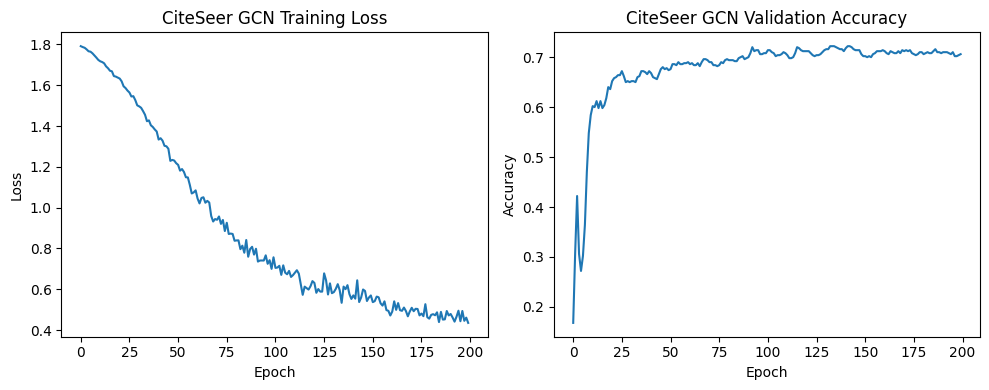

In [15]:
training_plot = plot_path / "training_curves.png"

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.plot(losses)
plt.title(dataset_name + " GCN Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.subplot(1, 2, 2)
plt.plot(val_accuracies)
plt.title(dataset_name + " GCN Validation Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.tight_layout()
plt.savefig(training_plot, dpi=150, bbox_inches="tight")
print("Saved:", training_plot)
plt.show()


Confusion matrix

Saved: C:\Users\DeAndre\Documents\Spring 2026\MAI\final_project\EEL6878_Final_Project\results\plots\gcn\20260502_153414_CiteSeer_GCN\confusion_matrix.png


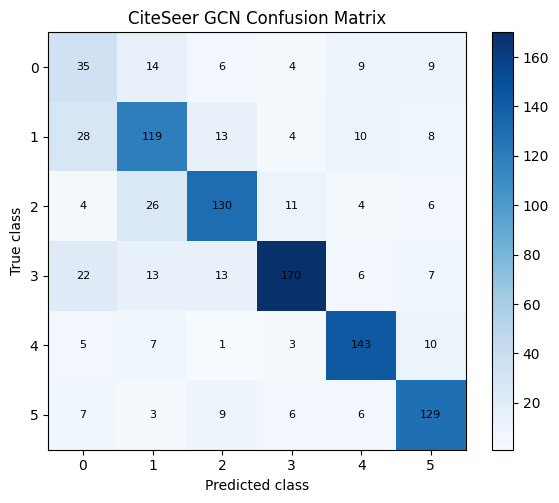

In [16]:
confusion_plot = plot_path / "confusion_matrix.png"
confusion = results["confusion_matrix"]

plt.figure(figsize=(6, 5))
plt.imshow(confusion, cmap="Blues")
plt.title(dataset_name + " GCN Confusion Matrix")
plt.xlabel("Predicted class")
plt.ylabel("True class")
plt.colorbar()

for i in range(len(confusion)):
    for j in range(len(confusion[i])):
        plt.text(j, i, confusion[i][j], ha="center", va="center", fontsize=8)

plt.tight_layout()
plt.savefig(confusion_plot, dpi=150, bbox_inches="tight")
print("Saved:", confusion_plot)
plt.show()
